In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline

In [ ]:
np.random.seed(42)

In [ ]:
X = np.linspace(0, 10, 40).reshape(-1,1)

In [ ]:
y = 2 + 0.5 * X[:,0] ** 2 + np.random.normal(0, 5, 40)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
degrees = [1,2,10]

In [ ]:
for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
        )
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    train_mse = mean_squared_error(y_train, train_predictions)
    test_mse = mean_squared_error(y_test, test_predictions)
    print(f"Polynomial Degree: {degree}")
    print(f"Train MSE: {train_mse:.2f}")
    print(f"Test MSE: {test_mse:.2f}")

Polynomial Degree: 1
Train MSE: 42.90
Test MSE: 42.99
Polynomial Degree: 2
Train MSE: 20.44
Test MSE: 19.79
Polynomial Degree: 10
Train MSE: 12.89
Test MSE: 95.21


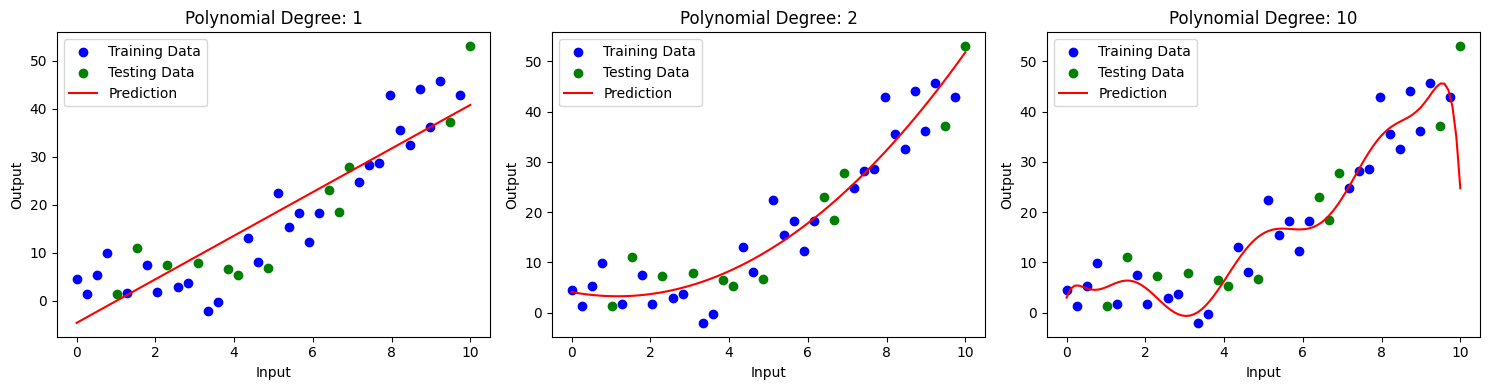

In [ ]:
X_plot = np.linspace(0, 10, 100).reshape(-1,1)
plt.figure(figsize=(15,4))
for ind, degree in enumerate(degrees):
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
        )
    model.fit(X_train, y_train)
    y_plot = model.predict(X_plot)
    plt.subplot(1, len(degrees), ind+1)
    plt.scatter(X_train, y_train, color="blue",label="Training Data")
    plt.scatter(X_test, y_test, color="green",label="Testing Data")
    plt.plot(X_plot, y_plot, color="red", label="Prediction")
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.title(f"Polynomial Degree: {degree}")
    plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
import numpy as np

In [ ]:
for degree in range(1,11):
  model = make_pipeline(
      PolynomialFeatures(degree=degree, include_bias=False),
      LinearRegression()
  )
  scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
  mean_mse = -scores.mean()
  print(f"Degree {degree}: CV MSE == {mean_mse:.2f}")

Degree 1: CV MSE == 110.69
Degree 2: CV MSE == 44.22
Degree 3: CV MSE == 71.23
Degree 4: CV MSE == 82.46
Degree 5: CV MSE == 1348.27
Degree 6: CV MSE == 11392.13
Degree 7: CV MSE == 53226.76
Degree 8: CV MSE == 99956.80
Degree 9: CV MSE == 1196598.07
Degree 10: CV MSE == 11490574.52
